In [ ]:
!pip install pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go


# time-series
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose


# Stationarity
from statsmodels.tsa.stattools import adfuller

# model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Cross Validation
import itertools
from sklearn.model_selection import TimeSeriesSplit
from pmdarima import ARIMA as PmdarimaARIMA, auto_arima
from pmdarima.model_selection import RollingForecastCV, cross_val_score

# Parameter Tuning
from sklearn.model_selection import ParameterGrid

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

In [ ]:
ffill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/ffill_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')

bfill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/bfill_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')

interpolation_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/interpolation_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')


target_feature = 'IN, COD'

for_validation = 160
for_test = 160

# Setting target feature

ffill_train_target = ffill_df[target_feature].iloc[:-for_validation-for_test]
ffill_train_inputs = ffill_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

ffill_val_target = ffill_df[target_feature].iloc[-for_validation-for_test:-for_test]
ffill_val_inputs = ffill_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

ffill_test_target = ffill_df[target_feature].iloc[-for_test:]
ffill_test_inputs = ffill_df.drop(columns=target_feature).iloc[-for_test:]


bfill_train_target = bfill_df[target_feature].iloc[:-for_validation-for_test]
bfill_train_inputs = bfill_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

bfill_val_target = bfill_df[target_feature].iloc[-for_validation-for_test:-for_test]
bfill_val_inputs = bfill_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

bfill_test_target = bfill_df[target_feature].iloc[-for_test:]
bfill_test_inputs = bfill_df.drop(columns=target_feature).iloc[-for_test:]


interpolation_train_target = interpolation_df[target_feature].iloc[:-for_validation-for_test]
interpolation_train_inputs = interpolation_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

interpolation_val_target = interpolation_df[target_feature].iloc[-for_validation-for_test:-for_test]
interpolation_val_inputs = interpolation_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

interpolation_test_target = interpolation_df[target_feature].iloc[-for_test:]
interpolation_test_inputs = interpolation_df.drop(columns=target_feature).iloc[-for_test:]

In [ ]:
print(f"ffill_train_target shape: {ffill_train_target.shape}")
print(f"ffill_val_target shape: {ffill_val_target.shape}")
print(f"ffill_test_target shape: {ffill_test_target.shape}")

print(f"bfill_train_target shape: {bfill_train_target.shape}")
print(f"bfill_val_target shape: {bfill_val_target.shape}")
print(f"bfill_test_target shape: {bfill_test_target.shape}")

print(f"interpolation_train_target shape: {interpolation_train_target.shape}")
print(f"interpolation_val_target shape: {interpolation_val_target.shape}")
print(f"interpolation_test_target shape: {interpolation_test_target.shape}")

ffill_train_target shape: (858,)
ffill_val_target shape: (160,)
ffill_test_target shape: (160,)
bfill_train_target shape: (855,)
bfill_val_target shape: (160,)
bfill_test_target shape: (160,)
interpolation_train_target shape: (858,)
interpolation_val_target shape: (160,)
interpolation_test_target shape: (160,)


# Modeling

- Univarite Forecasting (Holt-Winters, ARIMA, and SARIMA)
- Forecasting with Exogenous Features (SARIMAX)

## Holt-Winters

In [ ]:
# Alpha

def exp_tuning_alpha(n_splits: int,
                     alphas: list[float],
                     df: pd.DataFrame):

  tscv = TimeSeriesSplit(n_splits=n_splits)
  error_list = []

  for alpha in alphas:

    errors = []

    for train_index, test_index in tscv.split(df):

      train_data = df.iloc[train_index]
      test_data = df.iloc[test_index]

      model = ExponentialSmoothing(train_data,
                                   trend='add',
                                   seasonal='add',
                                   seasonal_periods=30,
                                   freq='D')\
                                   .fit(smoothing_level=alpha)

      predictions = model.forecast(len(test_data))
      rmse = root_mean_squared_error(test_data, predictions)
      errors.append(rmse)

    error_list.append({'Alpha': alpha, 'RMSE': np.mean(errors)})

  return pd.DataFrame(error_list)



def plot_error_cv_alpha(df: pd.DataFrame,
                  title: str):
  fig = px.line(df,
                x='Alpha',
                y='RMSE',
                title=title)
  fig.update_layout(template='simple_white', font=dict(size=18),
                    title_text =title,
                    width=800,
                    title_x = 0.5,
                    height = 400)
  fig.show()

# Beta

def exp_tuning_beta(n_splits: int,
                             betas: list[float],
                             df: pd.DataFrame):

  tscv = TimeSeriesSplit(n_splits=n_splits)
  error_list = []

  for beta in betas:

    errors = []

    for train_index, test_index in tscv.split(df):

      train_data = df.iloc[train_index]
      test_data = df.iloc[test_index]

      model = ExponentialSmoothing(train_data,
                                   trend='add',
                                   seasonal='add',
                                   seasonal_periods=30,
                                   freq='D')\
                                   .fit(smoothing_level=0.8, smoothing_trend=beta)

      predictions = model.forecast(len(test_data))
      rmse = root_mean_squared_error(test_data, predictions)
      errors.append(rmse)

    error_list.append({'Beta': beta, 'RMSE': np.mean(errors)})

  return pd.DataFrame(error_list)

def plot_error_cv_beta(df: pd.DataFrame,
                  title: str):

  fig = px.line(df,
                x='Beta',
                y='RMSE',
                title=title)
  fig.update_layout(template='simple_white', font=dict(size=18),
                    title_text =title,
                    width=800,
                    title_x = 0.5,
                    height = 400)
  fig.show()

 # Gama

def exp_tuning_gamma(n_splits: int,
                             gammas: list[float],
                             df: pd.DataFrame):

  tscv = TimeSeriesSplit(n_splits=n_splits)
  error_list = []

  for gamma  in gammas:

    errors = []

    for train_index, test_index in tscv.split(df):

      train_data = df.iloc[train_index]
      test_data = df.iloc[test_index]

      model = ExponentialSmoothing(train_data,
                                   trend='add',
                                   seasonal='add',
                                   seasonal_periods=30,
                                   freq='D')\
                                   .fit(smoothing_level=0.8, smoothing_trend=0.1, smoothing_seasonal = gamma)

      predictions = model.forecast(len(test_data))
      rmse = root_mean_squared_error(test_data, predictions)
      errors.append(rmse)

    error_list.append({'Gamma': gamma, 'RMSE': np.mean(errors)})

  return pd.DataFrame(error_list)

def plot_error_cv_gamma(df: pd.DataFrame,
                  title: str):

  fig = px.line(df,
                x='Gamma',
                y='RMSE',
                title=title)
  fig.update_layout(template='simple_white', font=dict(size=18),
                    title_text =title,
                    width=800,
                    title_x = 0.5,
                    height = 400)
  fig.show()

In [ ]:
ffill_error_alpha = exp_tuning_alpha(n_splits=5,
                                     alphas=np.arange(0.1,1,0.1),
                                     df=ffill_train_target
                                     )
ffill_error_beta = exp_tuning_beta(n_splits=5,
                                     betas=np.arange(0.1,1,0.1),
                                     df=ffill_train_target
                                     )
ffill_error_gamma = exp_tuning_gamma(n_splits=5,
                                     gammas=np.arange(0.1,1,0.1),
                                     df=ffill_train_target
                                     )

In [ ]:
plot_error_cv_alpha(ffill_error_alpha,
                    'Alpha Tuning for Holt-Winters (ffill dataset)')

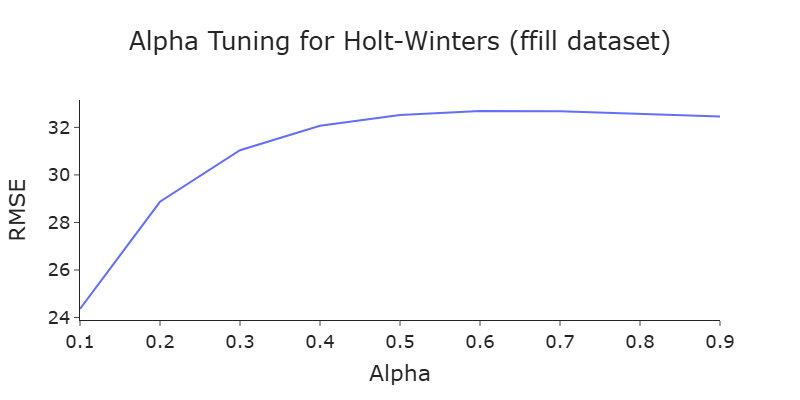

In [ ]:
plot_error_cv_beta(ffill_error_beta,
                    'Beta Tuning for Holt-Winters (ffill dataset)')

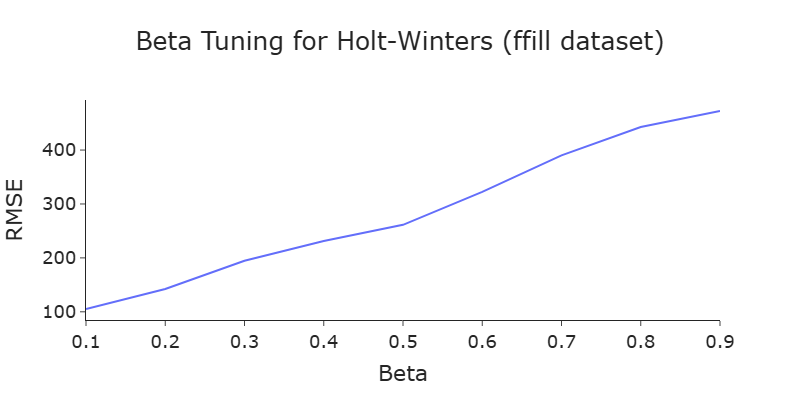

In [ ]:
plot_error_cv_gamma(ffill_error_gamma,
                    'Gamma Tuning for Holt-Winters (ffill dataset)')

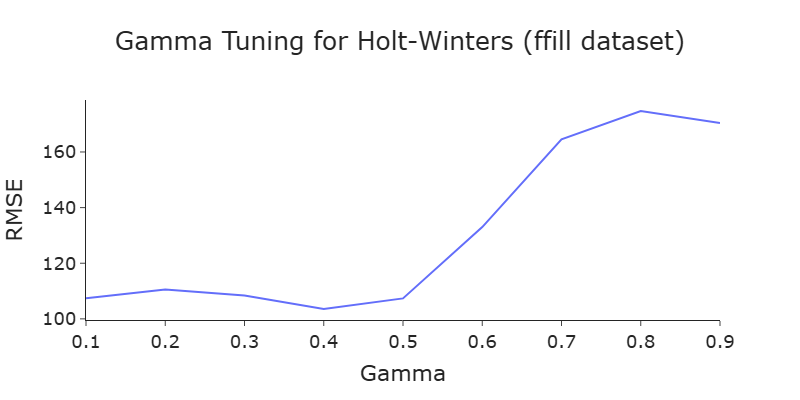

In [ ]:
ffill_holt_winters_params = {
    'smoothing_level': 0.1,
    'smoothing_trend': 0,
    'smoothing_seasonal': 0
}

In [ ]:
bfill_error_alpha = exp_tuning_alpha(n_splits=5,
                                     alphas=np.arange(0.1,1,0.1),
                                     df=bfill_train_target
                                     )
bfill_error_beta = exp_tuning_beta(n_splits=5,
                                     betas=np.arange(0.1,1,0.1),
                                     df=bfill_train_target
                                     )
bfill_error_gamma = exp_tuning_gamma(n_splits=5,
                                     gammas=np.arange(0.1,1,0.1),
                                     df=bfill_train_target
                                     )

In [ ]:
plot_error_cv_alpha(bfill_error_alpha,
                    'Alpha Tuning for Holt-Winters (bfill dataset)')

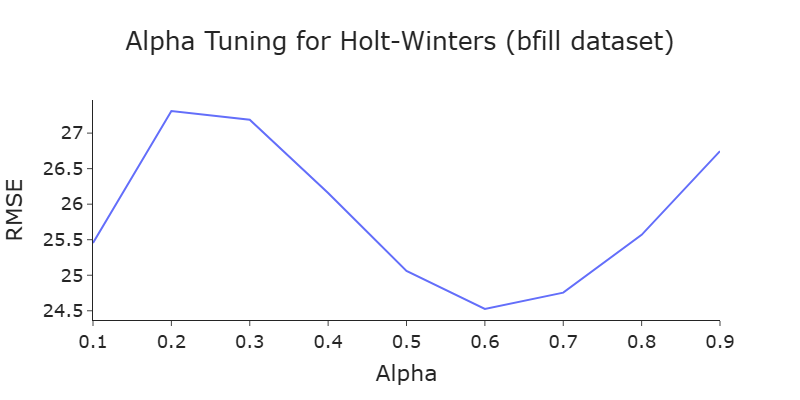

In [ ]:
plot_error_cv_beta(bfill_error_beta,
                    'Beta Tuning for Holt-Winters (bfill dataset)')

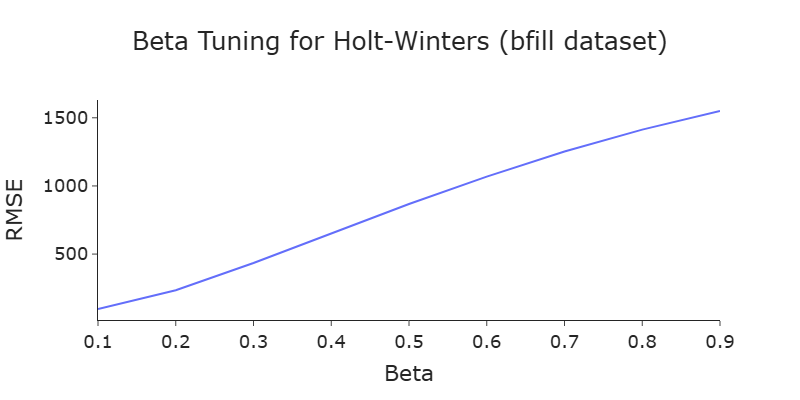

In [ ]:
plot_error_cv_gamma(bfill_error_gamma,
                    'Gamma Tuning for Holt-Winters (bfill dataset)')

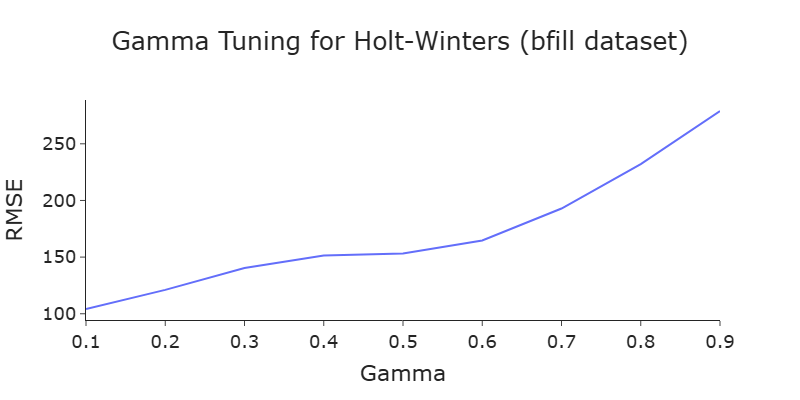

In [ ]:
bfill_holt_winters_params = {
    'smoothing_level': 0.6,
    'smoothing_trend': 0,
    'smoothing_seasonal': 0
}

In [ ]:
interpolation_error_alpha = exp_tuning_alpha(n_splits=5,
                                     alphas=np.arange(0.1,1,0.1),
                                     df=interpolation_train_target
                                     )
interpolation_error_beta = exp_tuning_beta(n_splits=5,
                                     betas=np.arange(0.1,1,0.1),
                                     df=interpolation_train_target
                                     )
interpolation_error_gamma = exp_tuning_gamma(n_splits=5,
                                     gammas=np.arange(0.1,1,0.1),
                                     df=interpolation_train_target
                                     )

In [ ]:
plot_error_cv_alpha(interpolation_error_alpha,
                    'Alpha Tuning for Holt-Winters (interpolation dataset)')

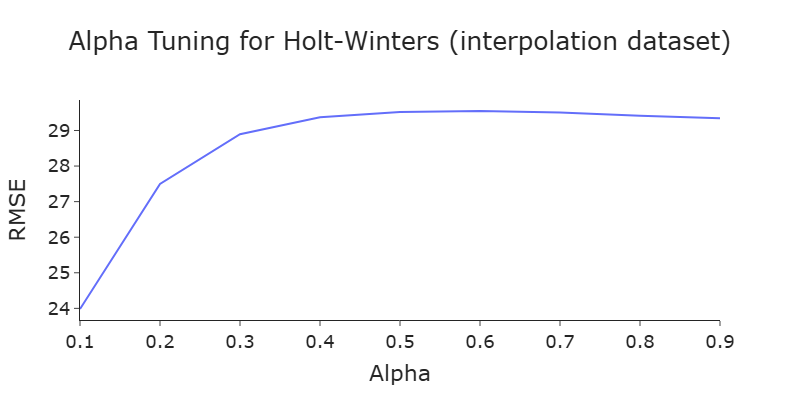

In [ ]:
plot_error_cv_beta(interpolation_error_beta,
                    'Beta Tuning for Holt-Winters (interpolation dataset)')

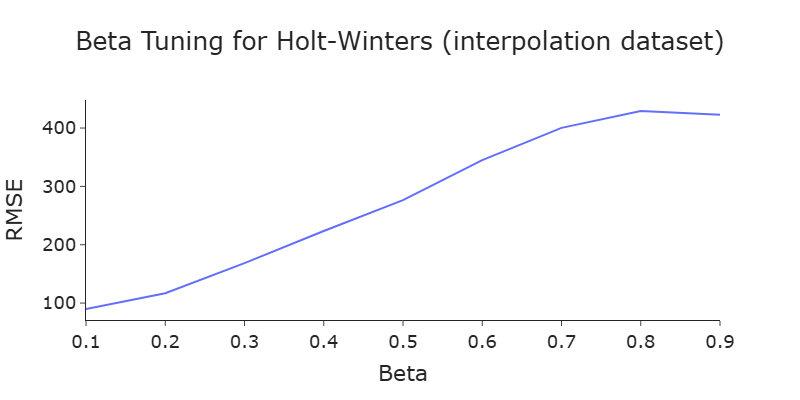

In [ ]:
plot_error_cv_gamma(interpolation_error_gamma,
                    'Gamma Tuning for Holt-Winters (interpolation dataset)')

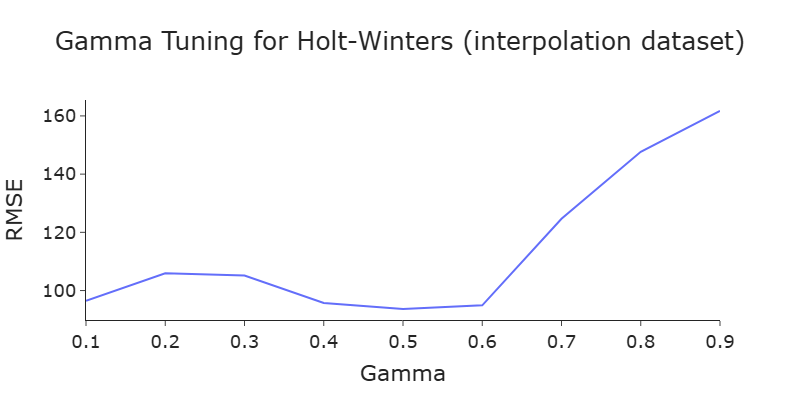

In [ ]:
interpolation_holt_winters_params = {
    'smoothing_level': 0.1,
    'smoothing_trend': 0,
    'smoothing_seasonal': 0
}

In [ ]:

"""
No seasonal trend detected in the Influent COD Autocorrelation analysis.
"""

# Holt-Winters Models

model_hw_ffill = ExponentialSmoothing(ffill_train_target,
                                     trend='add',
                                     seasonal_periods=0,
                                     freq='D')\
                                     .fit(**ffill_holt_winters_params)

model_hw_bfill = ExponentialSmoothing(bfill_train_target,
                                     trend='add',
                                     seasonal_periods=0,
                                     freq='D')\
                                     .fit(**bfill_holt_winters_params)

model_hw_interpolation = ExponentialSmoothing(interpolation_train_target,
                                     trend='add',
                                     seasonal_periods=0,
                                     freq='D')\
                                     .fit(**interpolation_holt_winters_params)

# Holt-Winters Prediction

hw_ffill_pred = model_hw_ffill.forecast(for_validation)
hw_bfill_pred = model_hw_bfill.forecast(for_validation)
hw_interpolation_pred = model_hw_interpolation.forecast(for_validation)

In [ ]:
def model_assessment_plot(train_df, val_df, pred_df,title):
  plt.plot(train_df, label=f'Train Data of ({train_df.name})')
  plt.plot(val_df, label=f'Validation Data of ({val_df.name})')
  plt.plot(pred_df, label=f'Predicted Data of ({pred_df.name})')

  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD Values')
  plt.title(f'{title}')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, pred_df)
  mae = mean_absolute_error(val_df, pred_df)
  mape = mean_absolute_percentage_error(val_df, pred_df)
  r_2 = r2_score(val_df, pred_df)

  print(f'RMSE: {rmse}')
  print(f'MAE: {mae}')
  print(f'MAPE: {mape}')
  print(f'R2 Score: {r_2}')


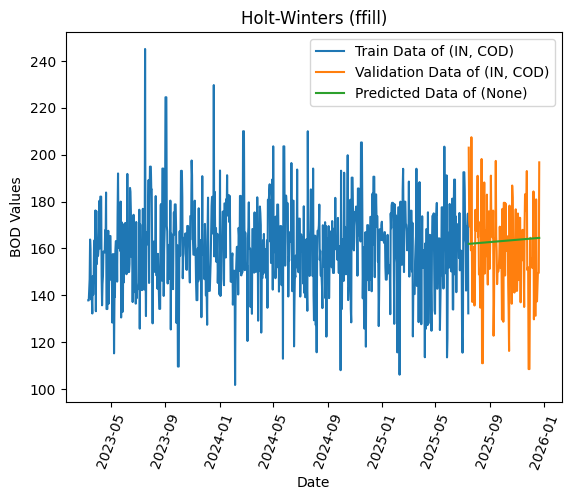

RMSE: 19.864310313174506
MAE: 15.379210867927569
MAPE: 0.1047337697469084
R2 Score: -0.07975246647093615


In [ ]:
model_assessment_plot(ffill_train_target, ffill_val_target, hw_ffill_pred, 'Holt-Winters (ffill)')

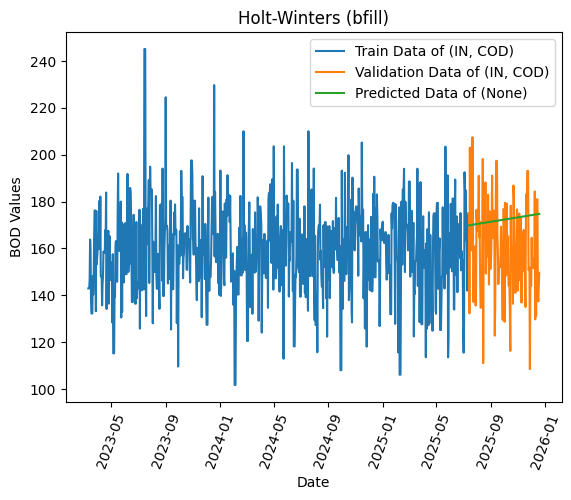

RMSE: 23.404065656492513
MAE: 19.438813629773737
MAPE: 0.13220350690666977
R2 Score: -0.569686944853097


In [ ]:
model_assessment_plot(bfill_train_target, bfill_val_target, hw_bfill_pred, 'Holt-Winters (bfill)')

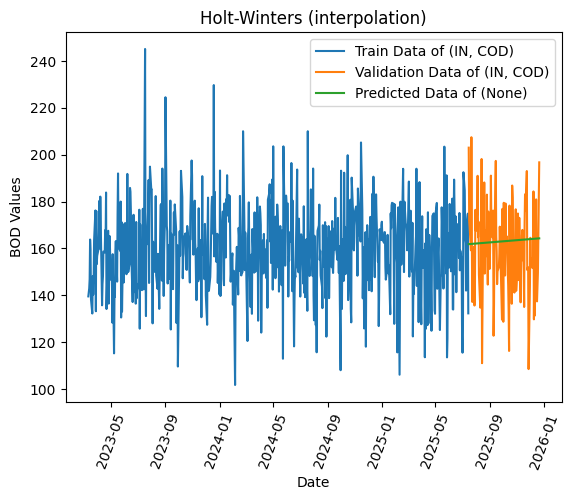

RMSE: 18.464587100614768
MAE: 14.549855843268414
MAPE: 0.09629924427077603
R2 Score: -0.07013385337362954


In [ ]:
model_assessment_plot(interpolation_train_target, interpolation_val_target, hw_interpolation_pred, 'Holt-Winters (interpolation)')

# ARIMA

In [ ]:
# Rechecking Stationary

def check_stationary(df):

  result = adfuller(df['IN, COD'])

  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print('\t%s: %.3f' % (key, value))

  if result[1] < 0.05:
    print('The p-value falls in the  category of STATIONARY time-series.')
  else:
    print('The time-series data is not stationary.')

In [ ]:
check_stationary(ffill_df)

ADF Statistic: -17.622814
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
The p-value falls in the  category of STATIONARY time-series.


In [ ]:
check_stationary(bfill_df)

ADF Statistic: -18.329538
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
The p-value falls in the  category of STATIONARY time-series.


In [ ]:
check_stationary(interpolation_df)

ADF Statistic: -24.555487
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
The p-value falls in the  category of STATIONARY time-series.


---
These findings indicate that the implementation of seasonal differencing is unnecessary for this data.
---



In [ ]:
# ARIMA MODEL

"""
Based on the seasonal decomposition analysis, the influent COD data
does not exhibit a significant seasonal pattern.
"""


def predict_and_plot_arima(train_df, val_df,imputation_method):

  model_arima = auto_arima(train_df,
                           seasonal = False)

  display(model_arima.summary())

  arima_pred = model_arima.predict(n_periods=len(val_df))

  plt.plot(train_df, label='Train Data')
  plt.plot(val_df, label='Validation Data')
  plt.plot(arima_pred, label= 'Predictions')
  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD')
  plt.title(f'Forecast Plot for ARIMA Model {imputation_method} method')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, arima_pred)
  mae = mean_absolute_error(val_df, arima_pred)
  mape = mean_absolute_percentage_error(val_df, arima_pred)

  print(f"ARIMA {imputation_method} RMSE: {rmse}")
  print(f"ARIMA {imputation_method} MAE: {mae}")
  print(f"ARIMA {imputation_method} MAPE: {mape}")

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -3681.606
Date:                Sat, 25 Jul 2026   AIC                           7373.212
Time:                        07:23:07   BIC                           7396.985
Sample:                    03-11-2023   HQIC                          7382.314
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    111.7879      7.366     15.176      0.000      97.351     126.225
ar.L1          0.2688      0.028      9.577      0.000       0.214       0.324
ar.L2          0.0845      0.032      2.665      0.008       0.022       0.147
ar.L3         -0.0501      0.038     -1.327      0.185      -0.124       0.024
sigma2       312.3863     11.862     26.335      0.000     289.137     335.636
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.15
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                             0.11
Prob(H) (two-sided):                  0.93   Kurtosis:                         4.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

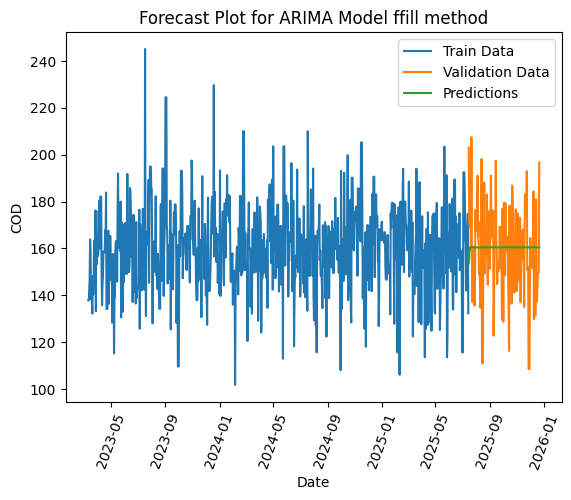

ARIMA ffill RMSE: 19.356104232235722
ARIMA ffill MAE: 15.134246298463623
ARIMA ffill MAPE: 0.10136455559663009


In [ ]:
predict_and_plot_arima(ffill_train_target, ffill_val_target, 'ffill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  855
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -3686.139
Date:                Sat, 25 Jul 2026   AIC                           7380.278
Time:                        07:23:21   BIC                           7399.282
Sample:                    03-11-2023   HQIC                          7387.555
                         - 07-12-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     95.9484      4.851     19.779      0.000      86.440     105.456
ar.L1          0.3139      0.026     12.129      0.000       0.263       0.365
ar.L2          0.0812      0.029      2.771      0.006       0.024       0.139
sigma2       325.2162     12.240     26.571      0.000     301.227     349.205
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                75.67
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                             0.22
Prob(H) (two-sided):                  0.65   Kurtosis:                         4.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

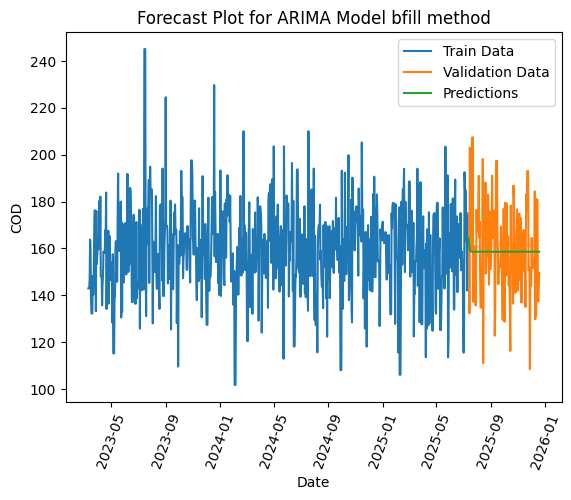

ARIMA bfill RMSE: 18.63871527641592
ARIMA bfill MAE: 14.851191213115618
ARIMA bfill MAPE: 0.09556432771900511


In [ ]:
predict_and_plot_arima(bfill_train_target, bfill_val_target, 'bfill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -3636.014
Date:                Sat, 25 Jul 2026   AIC                           7278.029
Time:                        07:23:29   BIC                           7292.292
Sample:                    03-11-2023   HQIC                          7283.490
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    107.5025      4.078     26.362      0.000      99.510     115.495
ar.L1          0.3261      0.025     12.904      0.000       0.277       0.376
sigma2       280.6842     10.860     25.846      0.000     259.399     301.969
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                52.92
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               1.04   Skew:                             0.15
Prob(H) (two-sided):                  0.72   Kurtosis:                         4.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

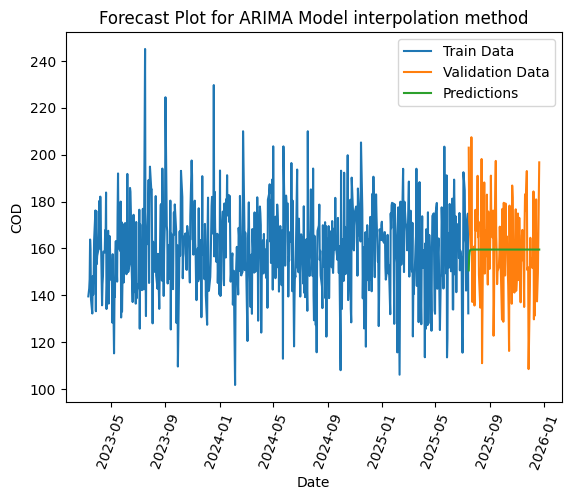

ARIMA interpolation RMSE: 18.029929675134074
ARIMA interpolation MAE: 14.039994138848636
ARIMA interpolation MAPE: 0.09099180754180093


In [ ]:
predict_and_plot_arima(interpolation_train_target, interpolation_val_target, 'interpolation')

# SARIMA

In [ ]:
# SARIMA MODEL

def predict_and_plot_sarima(train_df, val_df,imputation_method):

  model_sarima = auto_arima(train_df,
                            m=7,
                           seasonal = True)

  display(model_sarima.summary())

  sarima_pred = model_sarima.predict(n_periods=len(val_df))

  plt.plot(train_df, label='Train Data')
  plt.plot(val_df, label='Validation Data')
  plt.plot(sarima_pred, label= 'Predictions')
  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD')
  plt.title(f'Forecast Plot for SARIMA Model {imputation_method} method')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, sarima_pred)
  mae = mean_absolute_error(val_df, sarima_pred)
  mape = mean_absolute_percentage_error(val_df, sarima_pred)

  print(f"SARIMA {imputation_method} RMSE: {rmse}")
  print(f"SARIMA {imputation_method} MAE: {mae}")
  print(f"SARIMA {imputation_method} MAPE: {mape}")

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -3681.606
Date:                Sat, 25 Jul 2026   AIC                           7373.212
Time:                        07:24:21   BIC                           7396.985
Sample:                    03-11-2023   HQIC                          7382.314
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    111.7879      7.366     15.176      0.000      97.351     126.225
ar.L1          0.2688      0.028      9.577      0.000       0.214       0.324
ar.L2          0.0845      0.032      2.665      0.008       0.022       0.147
ar.L3         -0.0501      0.038     -1.327      0.185      -0.124       0.024
sigma2       312.3863     11.862     26.335      0.000     289.137     335.636
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.15
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                             0.11
Prob(H) (two-sided):                  0.93   Kurtosis:                         4.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

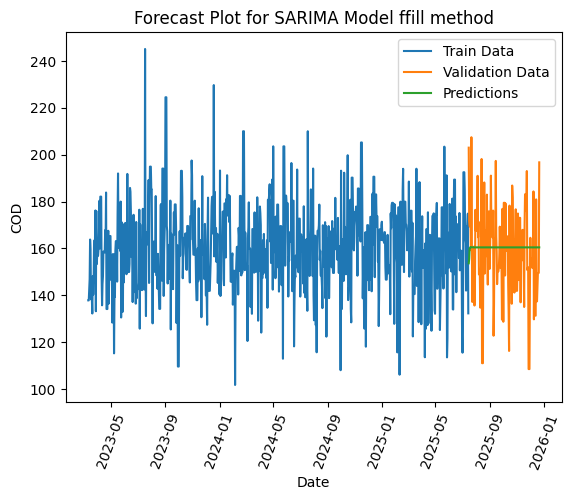

SARIMA ffill RMSE: 19.356104232235722
SARIMA ffill MAE: 15.134246298463623
SARIMA ffill MAPE: 0.10136455559663009


In [ ]:
predict_and_plot_sarima(ffill_train_target, ffill_val_target, 'ffill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  855
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -3686.139
Date:                Sat, 25 Jul 2026   AIC                           7380.278
Time:                        07:24:50   BIC                           7399.282
Sample:                    03-11-2023   HQIC                          7387.555
                         - 07-12-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     95.9484      4.851     19.779      0.000      86.440     105.456
ar.L1          0.3139      0.026     12.129      0.000       0.263       0.365
ar.L2          0.0812      0.029      2.771      0.006       0.024       0.139
sigma2       325.2162     12.240     26.571      0.000     301.227     349.205
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                75.67
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                             0.22
Prob(H) (two-sided):                  0.65   Kurtosis:                         4.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

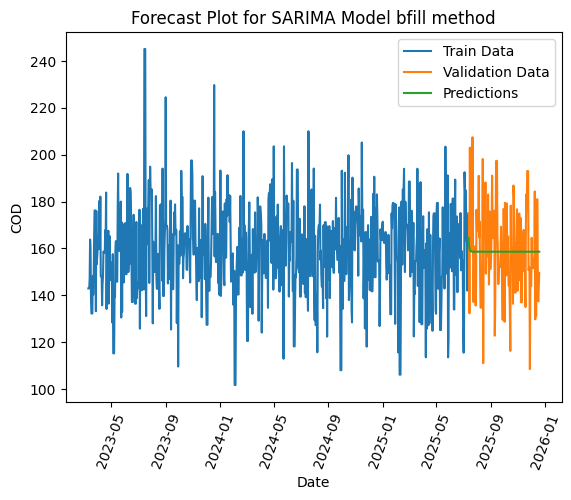

SARIMA bfill RMSE: 18.63871527641592
SARIMA bfill MAE: 14.851191213115618
SARIMA bfill MAPE: 0.09556432771900511


In [ ]:
predict_and_plot_sarima(bfill_train_target, bfill_val_target, 'bfill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -3636.014
Date:                Sat, 25 Jul 2026   AIC                           7278.029
Time:                        07:25:06   BIC                           7292.292
Sample:                    03-11-2023   HQIC                          7283.490
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    107.5025      4.078     26.362      0.000      99.510     115.495
ar.L1          0.3261      0.025     12.904      0.000       0.277       0.376
sigma2       280.6842     10.860     25.846      0.000     259.399     301.969
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                52.92
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               1.04   Skew:                             0.15
Prob(H) (two-sided):                  0.72   Kurtosis:                         4.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

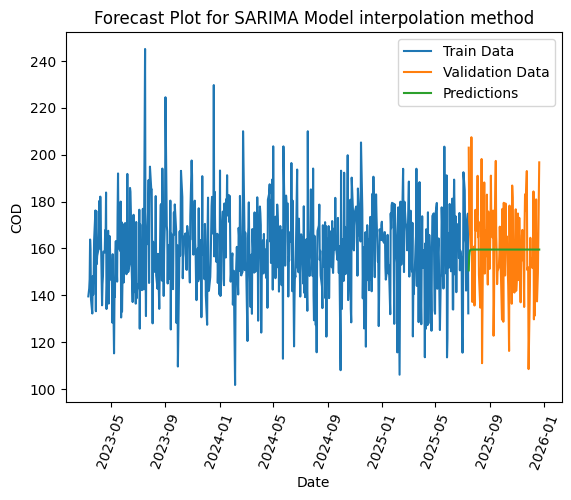

SARIMA interpolation RMSE: 18.029929675134074
SARIMA interpolation MAE: 14.039994138848636
SARIMA interpolation MAPE: 0.09099180754180093


In [ ]:
predict_and_plot_sarima(interpolation_train_target, interpolation_val_target, 'interpolation')

# SARIMAX

## SARIMAX Cross Validation

- Since the seasonal decomposition did not reveal significant seasonal pattern and the automatic model selection procedure identified no seasonaL differencing, or moving average terms (P = D = Q = 0), only the non-seasonal orders (p, d, and q) were evaluated during time-series cross-validation.

In [ ]:
parameter_grid = {
    'p': np.arange(0, 3),
    'd': np.arange(0, 3),
    'q': np.arange(0, 3)
}

grid_cross_val = ParameterGrid(parameter_grid)

def sarimax_cross_validation(train_df, train_df_target, train_df_inputs):

    results = []

    cross_val = RollingForecastCV(
        h=30,
        step=60,
        initial=650
    )

    for params in grid_cross_val:

        model_cv = PmdarimaARIMA(
            order=(params['p'], params['d'], params['q']),
            seasonal_order=(0, 0, 0, 7)
        )

        cv_score = cross_val_score(
            model_cv,
            y=train_df_target,
            X=train_df_inputs,
            scoring='mean_squared_error',
            cv=cross_val,
            verbose=1
        )

        results.append({
            'p': params['p'],
            'd': params['d'],
            'q': params['q'],
            'MSE': np.mean(cv_score)
        })

    return pd.DataFrame(results)

In [ ]:
sarimax_cross_validation(interpolation_df, interpolation_train_target, interpolation_train_inputs)

- p = 0
- d = 0
- q = 0

In [ ]:
# Final SARIMAX Model

"""
Based on the results of the different models,
the dataset generated using time interpolation
produced the lowest prediction errors.
Therefore, this imputed dataset was selected for developing
the final forecasting model.
"""

model_sarimax_final = PmdarimaARIMA(order = (0,0,0),
                                    seasonal_order = (0,0,0,7)).fit(interpolation_train_target, interpolation_train_inputs)

In [ ]:
model_sarimax_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:                        SARIMAX   Log Likelihood               -3034.851
Date:                Sun, 26 Jul 2026   AIC                           6139.703
Time:                        08:58:39   BIC                           6306.114
Sample:                    03-11-2023   HQIC                          6203.418
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                 -0.0001        nan        nan        nan         nan         nan
IN, PH                    -0.1048      0.892     -0.117      0.906      -1.853       1.644
IN, NO3-N                  0.7458      0.578      1.291      0.197      -0.387       1.878
IN, Fecal Coli          3.352e-07   7.26e-07      0.462      0.644   -1.09e-06    1.76e-06
IN, Oil & Grease          -0.0185      0.303     -0.061      0.951      -0.612       0.575
IN, PO4-P                 12.2528      0.905     13.542      0.000      10.479      14.026
IN, Surfactants (MBAS)     3.3069      1.334      2.480      0.013       0.693       5.921
IN, TSS                    0.4855      0.025     19.335      0.000       0.436       0.535
IN, NH3-N                  1.5490      0.162      9.551      0.000       1.231       1.867
IN, Flow (m³/hr)           0.0036      0.003      1.038      0.299      -0.003       0.010
lag1_pH                    1.9278      0.912      2.114      0.035       0.141       3.715
lag1_NO3                  -0.6968      0.590     -1.181      0.238      -1.853       0.460
lag1_Fecal Coli         -8.19e-07   7.26e-07     -1.129      0.259   -2.24e-06    6.03e-07
lag3_Fecal Coli         5.712e-07   7.46e-07      0.766      0.444    -8.9e-07    2.03e-06
lag1_COD                   0.2941      0.031      9.573      0.000       0.234       0.354
lag1_PO4-P                -2.5206      1.003     -2.514      0.012      -4.486      -0.555
lag1_TSS                  -0.1752      0.028     -6.288      0.000      -0.230      -0.121
lag1_NH3                  -0.5183      0.170     -3.052      0.002      -0.851      -0.185
lag1_Flow Rate            -0.0038      0.004     -1.061      0.289      -0.011       0.003
lag2_Flow Rate            -0.0021      0.004     -0.574      0.566      -0.009       0.005
lag3_Flow Rate             0.0029      0.003      0.827      0.409      -0.004       0.010
lag4_Flow Rate            -0.0012      0.004     -0.331      0.741      -0.008       0.006
lag5_Flow Rate             0.0041      0.003      1.190      0.234      -0.003       0.011
lag6_Flow Rate            -0.0040      0.003     -1.131      0.258      -0.011       0.003
lag7_Flow Rate             0.0052      0.004      1.432      0.152      -0.002       0.012
lag10_Flow Rate           -0.0051      0.003     -1.470      0.142      -0.012       0.002
Day                       -0.0018      0.034     -0.053      0.958      -0.069       0.065
Month                      0.1072      0.114      0.943      0.346      -0.116       0.330
Year                       0.0052      0.005      1.003      0.316      -0.005       0.015
Weekday                    0.1913      0.228      0.839      0.401      -0.256       0.638
Weekend                    0.3306      1.201      0.275      0.783      -2.024       2.685
Holiday                   -0.7669      1.464     -0.524      0.600      -3.636       2.102
Rainfall                   0.5252      0.859      0.611 

In [ ]:
# Prediction

final_prediction_COD = model_sarimax_final.predict(n_periods = len(interpolation_val_target),
                                                   X = interpolation_val_inputs)

final_prediction_COD = final_prediction_COD.rename('SARIMAX, COD')

In [ ]:
# Generate predictions for the test set
test_prediction_COD = model_sarimax_final.predict(n_periods = len(interpolation_test_target),
                                                 X = interpolation_test_inputs)

test_prediction_COD = test_prediction_COD.rename('SARIMAX, COD')

In [ ]:
# Plotting

import matplotlib.ticker as mticker

def model_assessment_plot(train_df, val_df, pred_df, chart_title):

  plt.plot(train_df, label=f'Train Data of ({train_df.name})')
  plt.plot(val_df, label=f'Validation Data of ({val_df.name})')
  plt.plot(pred_df, label=f'Predicted Value')

  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD Values')
  plt.title(f'{chart_title}')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, pred_df)
  mae = mean_absolute_error(val_df, pred_df)
  mape = mean_absolute_percentage_error(val_df, pred_df)

  print(f"{chart_title} RMSE: {rmse}")
  print(f"{chart_title} MAE: {mae}")
  print(f"{chart_title} MAPE: {mape}")

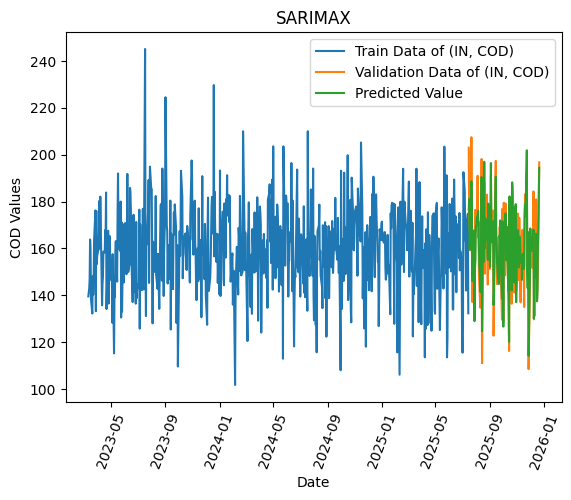

SARIMAX RMSE: 8.573456486127458
SARIMAX MAE: 6.88098622604812
SARIMAX MAPE: 0.04385289385157111


In [ ]:
model_assessment_plot(interpolation_train_target,
                      interpolation_val_target,
                      final_prediction_COD,
                      'SARIMAX'
)

## Residual Analysis and R2 Score

In [ ]:
# Residual Analysis

def residual_analysis(val_df, pred_df):

  residuals = val_df - pred_df

  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=pred_df, y=residuals, alpha=0.6)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.xlabel('Predicted Values')
  plt.ylabel('Residuals')
  plt.title('Residual Plot')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

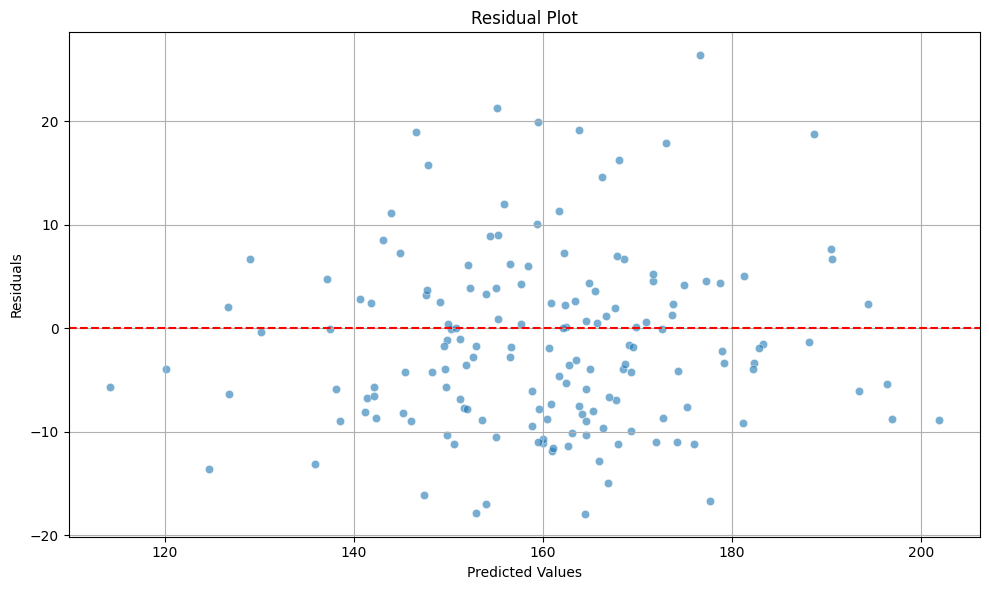

In [ ]:
residual_analysis(interpolation_val_target,
                  final_prediction_COD
)

In [ ]:
def r2_score_plot(y_val, y_prediction, model):
    r2 = r2_score(y_val, y_prediction)
    y_val, y_prediction = np.asarray(y_val), np.asarray(y_prediction)

    min_val = min(y_val.min(), y_prediction.min())
    max_val = max(y_val.max(), y_prediction.max())

    plt.figure(figsize=(8, 6))
    plt.scatter(y_val, y_prediction, alpha=0.7, edgecolor='black', label='Predictions')
    plt.plot([min_val, max_val], [min_val, max_val],
             '--', color='red', linewidth=2, label='Perfect Prediction')

    plt.xlabel('Actual COD (mg/L)')
    plt.ylabel('Predicted COD (mg/L)')
    plt.title(f'{model} Model: Actual vs. Predicted COD', fontweight='bold')

    plt.text(
        0.05, 0.95, f'$R^2$ = {r2:.3f}',
        transform=plt.gca().transAxes,
        fontsize=11, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='none',
                  edgecolor='black', linewidth=1)
    )

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

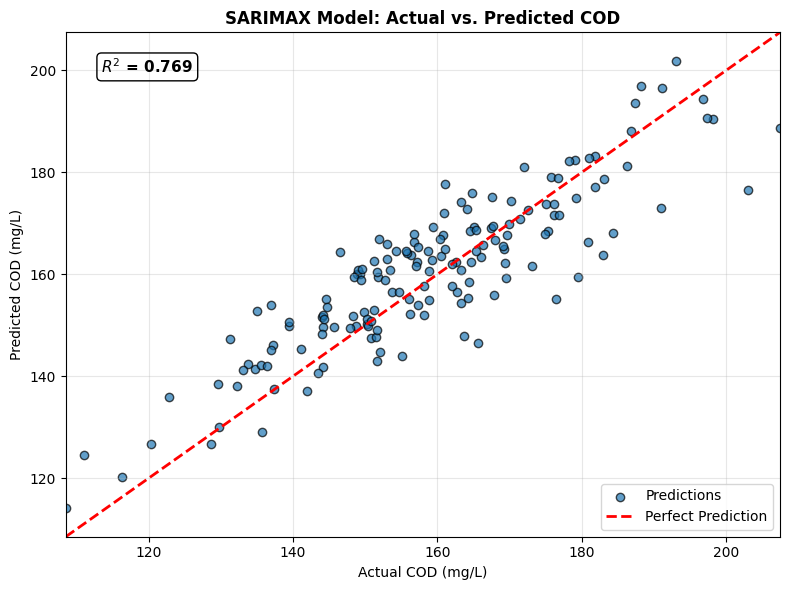

In [ ]:
r2_score_plot(interpolation_val_target,
              final_prediction_COD,
              'SARIMAX'
)

# Model Discussion (Time-Series Forecasting)
- The interpolation imputation method produced the least error amongst other imputation methods.

- **Holt-Winters** forecasting method yielded an **RMSE value of 18.46**.

- Both **ARIMA AND SARIMA** generated an **RMSE value of 18.03** which is slighly better than Holt-Winters Model.

- The **SARIMAX** model outperformed all other time-series forecasting methods, yielding the **lowest error score of 8.573** and an **R2 value of 0.769** which is slightly worse than the Linear Regression Model.

- A small number of isolated outliers at the extreme values indicate that the model may have some difficulty accurately predicting highly variable environmental peaks.